# Spatial basis verification: Chebyshev vs FEM

Before plugging two spatial discretisations into a full PDE solve, it
is worth checking that each basis can actually *represent* the input
data accurately at the resolution we plan to use. The TDS problem has
one sharp spatial feature: a 2.5 nm Gaussian ion source centered at
4.5 nm, embedded in a 20 µm domain. If a basis can't resolve that
source at its production DOF count, no amount of time-integration
accuracy will recover.

This notebook isolates the spatial representation question from
everything else (no PDE, no time-stepping, no Newton iterations) by
computing how well each grid interpolates the analytic Gaussian
source. If FESTIM's graded P1 mesh and the sinh-stretched Chebyshev
grid can both represent the source to below the 1% production error
budget, the production simulation is *not* bottlenecked by source
resolution and any error we observe in `tds_inverse.ipynb` lives
elsewhere (time stepper, trap reactions, surface-flux quadrature).


## 1. Setup

The geometry parameters match the workshop tutorial verbatim. The
ratio that matters is the source width to domain length:
$2.5\,\mathrm{nm} / 20\,\mu\mathrm{m} = 1.25 \times 10^{-4}$.
That's the spatial dynamic range each basis has to span on a single
mesh.


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

# tutorial geometry
L = 20e-6          # foil thickness (m)
CENTER = 4.5e-9    # Gaussian source center (m)
WIDTH = 2.5e-9     # Gaussian source standard deviation (m)


## 2. The analytic source

The ion source is a Gaussian normalised so its integral over the
real line is 1 (multiplied at run time by the incident ion flux to
give a volumetric source rate). Its peak value is
$1/(w\sqrt{2\pi}) \approx 1.6 \times 10^{8}\,\mathrm{m}^{-1}$
at $x = c$.

The "fine reference grid" `x_ref` is what we measure error against —
10 000 equispaced points across $[0, 30\,\mathrm{nm}]$. We
restrict to the source's support because the Gaussian is essentially
zero past 30 nm (more than 10 standard deviations from the peak), so
including the rest of the domain would just inflate the denominator
of the relative-L2 norm without measuring anything useful.


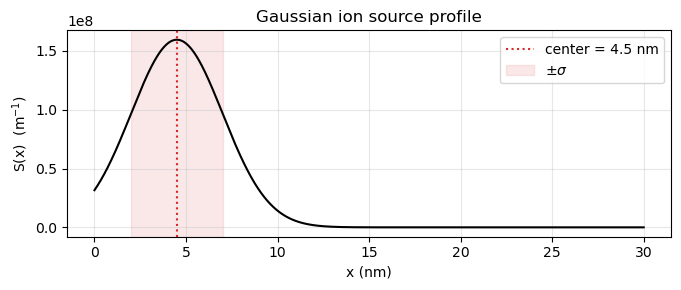

In [29]:
def gaussian_source(x):
    """Workshop-tutorial Gaussian source profile, evaluated at any x."""
    return (1.0 / (WIDTH * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - CENTER) / WIDTH) ** 2
    )

x_ref = np.linspace(0, 30e-9, 10000)
S_ref = gaussian_source(x_ref)

plt.figure(figsize=(7, 3))
plt.plot(x_ref * 1e9, S_ref, "k-", lw=1.5)
plt.axvline(CENTER * 1e9, color="C3", ls=":",
            label=f"center = {CENTER*1e9:.1f} nm")
plt.axvspan((CENTER - WIDTH) * 1e9, (CENTER + WIDTH) * 1e9,
            color="C3", alpha=0.1, label=r"$\pm \sigma$")
plt.xlabel("x (nm)"); plt.ylabel(r"S(x)  (m$^{-1}$)")
plt.title("Gaussian ion source profile")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()


## 3. The two grids

### 3.1 Chebyshev sinh-stretched nodes

The sinh-stretched Chebyshev-Gauss-Lobatto grid has $N+1$ nodes that
cluster near $x=0$ (where the source lives). Construction in three
steps:

1. **Standard CGL nodes** on $[-1, 1]$:
   $s_k = -\cos(k\pi / N)$ for $k = 0, \ldots, N$.
2. **Map to $[0, 1]$**:
   $s_k \mapsto \tfrac{1}{2}(1 - \cos(k\pi / N))$.
3. **Sinh stretch toward $x=0$**:
   $x_k = x_{\max} \cdot \sinh(\alpha s_k) / \sinh \alpha$,
   with $\alpha = 6$ (the production `left_stretch` value).

The polynomial interpolant through those $N+1$ nodes is what the
Chebyshev pseudospectral solver effectively uses to compute spatial
derivatives at every backward-Euler step.


In [30]:
def chebyshev_nodes(N, x_max=L, alpha=6.0):
    """Sinh-stretched Chebyshev-Gauss-Lobatto nodes on [0, x_max].
    N is the polynomial degree; total nodes = N+1."""
    k = np.arange(N + 1)
    s = 0.5 * (1.0 - np.cos(k * np.pi / N))   # CGL nodes mapped to [0, 1]
    x = x_max * np.sinh(alpha * s) / np.sinh(alpha)
    return x


### 3.2 FESTIM graded P1 vertices

Same recipe as the workshop tutorial: 200 vertices in $[0, 30\,
\mathrm{nm}]$ (the source region), 300 in
$[30\,\mathrm{nm}, 3\,\mu\mathrm{m}]$, and 200 in
$[3\,\mu\mathrm{m}, 20\,\mu\mathrm{m}]$. The `scale` knob
densifies all three blocks proportionally so we can sweep
resolution without changing the mesh shape.


In [31]:
def festim_graded_vertices(scale=1.0):
    """Workshop-tutorial graded mesh, optionally densified by `scale`."""
    n1 = max(2, int(round(200 * scale)))
    n2 = max(2, int(round(300 * scale)))
    n3 = max(2, int(round(200 * scale)))
    return np.concatenate([
        np.linspace(0, 30e-9, num=n1),
        np.linspace(30e-9, 3e-6, num=n2),
        np.linspace(3e-6, L, num=n3),
    ])


### 3.3 Where the nodes actually land

A quick visual sanity check of node placement inside the source
region. The two methods cluster their points very differently here:
the FEM mesh has uniform spacing inside $[0, 30\,\mathrm{nm}]$
(by construction), while Chebyshev's sinh stretch concentrates
nodes near $x = 0$.


Chebyshev: N+1 = 65 nodes total
FEM:       700 vertices total

Nodes inside source region [0, 30 nm]:
  Chebyshev: 10
  FEM:       199


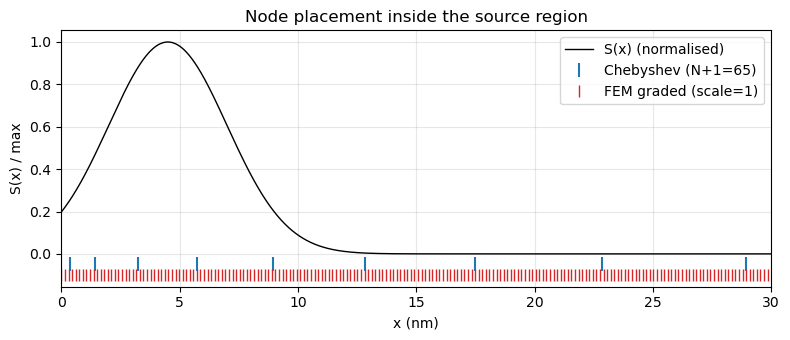

In [32]:
N_cheb = 64                          # production Chebyshev degree
v_fem = festim_graded_vertices(1.0)  # production FEM vertices
x_cheb = chebyshev_nodes(N_cheb)

print(f"Chebyshev: N+1 = {len(x_cheb):d} nodes total")
print(f"FEM:       {len(v_fem):d} vertices total")

mask_cheb = x_cheb < 30e-9
mask_fem = v_fem < 30e-9
print(f"\nNodes inside source region [0, 30 nm]:")
print(f"  Chebyshev: {mask_cheb.sum():d}")
print(f"  FEM:       {mask_fem.sum():d}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(x_ref * 1e9, S_ref / S_ref.max(), "k-", lw=1.0,
        label="S(x) (normalised)")
ax.plot(x_cheb[mask_cheb] * 1e9, np.full(mask_cheb.sum(), -0.05),
        "C0|", ms=10, mew=1.5, label=f"Chebyshev (N+1={N_cheb+1})")
ax.plot(v_fem[mask_fem] * 1e9, np.full(mask_fem.sum(), -0.10),
        "C3|", ms=8, mew=1.0, label=f"FEM graded (scale=1)")
ax.set_xlim(0, 30); ax.set_xlabel("x (nm)")
ax.set_ylabel("S(x) / max")
ax.set_title("Node placement inside the source region")
ax.grid(alpha=0.3); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()


## 4. Source representation error

For each method:

1. Evaluate the analytic Gaussian $S(x)$ at the discrete nodes /
   vertices.
2. Build the basis interpolant from those values.
3. Evaluate the interpolant on the fine reference grid `x_ref`.
4. Compute the relative-L2 norm of the difference against `S_ref`.

The two interpolants are:

- **Chebyshev**: a single global polynomial of degree $N$ passing
  through all $N+1$ nodes. We use SciPy's
  `BarycentricInterpolator`, which evaluates the Lagrange polynomial
  in barycentric form (numerically stable through $N \sim$
  hundreds).
- **FEM**: piecewise linear between adjacent vertices, exactly what
  P1 finite elements represent. `np.interp` does this in one line.

Crucially, no PDE is being solved here. We're just asking: given
this set of points, how well can each basis represent a function we
already know analytically?


In [33]:
def chebyshev_interp_error(N):
    """Sample S at sinh-stretched Chebyshev nodes, interpolate to x_ref via
    barycentric Lagrange, return relative L2 error."""
    x_nodes = chebyshev_nodes(N)
    S_nodes = gaussian_source(x_nodes)
    interp = BarycentricInterpolator(x_nodes, S_nodes)
    S_interp = interp(x_ref)
    return np.linalg.norm(S_interp - S_ref) / np.linalg.norm(S_ref)


def fem_interp_error(scale):
    """Sample S at graded P1 vertices, linearly interpolate to x_ref,
    return relative L2 error."""
    v = festim_graded_vertices(scale)
    S_verts = gaussian_source(v)
    S_interp = np.interp(x_ref, v, S_verts)
    return np.linalg.norm(S_interp - S_ref) / np.linalg.norm(S_ref)


### 4.1 Sweep over resolution

Run both error functions across the DOF ranges used in the
production convergence sweeps.


In [34]:
N_values = [16, 24, 32, 48, 64, 96, 128, 192, 256]
fem_scales = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]

cheb_errs = [chebyshev_interp_error(N) for N in N_values]
fem_errs = [fem_interp_error(s) for s in fem_scales]
fem_dofs = [len(festim_graded_vertices(s)) for s in fem_scales]
cheb_dofs = [N + 1 for N in N_values]

print("Chebyshev:")
for N, dofs, err in zip(N_values, cheb_dofs, cheb_errs):
    print(f"  N+1={dofs:>4d}   rel-L2 = {err:.2e}")

print("\nFEM (P1 graded):")
for s, dofs, err in zip(fem_scales, fem_dofs, fem_errs):
    print(f"  scale={s:>4}  vertices={dofs:>5d}  rel-L2 = {err:.2e}")


Chebyshev:
  N+1=  17   rel-L2 = 1.15e+00
  N+1=  25   rel-L2 = 4.98e-01
  N+1=  33   rel-L2 = 5.49e-01
  N+1=  49   rel-L2 = 2.52e-01
  N+1=  65   rel-L2 = 1.05e-01
  N+1=  97   rel-L2 = 2.14e-02
  N+1= 129   rel-L2 = 6.67e-04
  N+1= 193   rel-L2 = 1.13e-06
  N+1= 257   rel-L2 = 2.44e-09

FEM (P1 graded):
  scale= 0.1  vertices=   70  rel-L2 = 2.97e-02
  scale=0.25  vertices=  175  rel-L2 = 4.55e-03
  scale= 0.5  vertices=  350  rel-L2 = 1.12e-03
  scale=0.75  vertices=  525  rel-L2 = 4.94e-04
  scale= 1.0  vertices=  700  rel-L2 = 2.77e-04
  scale= 1.5  vertices= 1050  rel-L2 = 1.23e-04
  scale= 2.0  vertices= 1400  rel-L2 = 6.88e-05
  scale= 4.0  vertices= 2800  rel-L2 = 1.72e-05


### 4.2 The headline plot

Error vs DOFs on a log-log axis. Two qualitative features should be
visible:

1. **Chebyshev falls exponentially in $N$.** A smooth function (the
   Gaussian is $C^\infty$) interpolated on Chebyshev–Gauss–Lobatto
   nodes converges *spectrally* — error drops faster than any
   algebraic rate. On a log-log axis this looks like a curve that
   bends sharply downward.
2. **FEM falls quadratically in DOFs.** P1 elements interpolate a
   smooth function with $O(h^2)$ error, so the slope is roughly
   $-2$ on a log-log axis. The graded mesh helps the constant
   factor by clustering vertices near the source, but it doesn't
   change the slope.

The vertical gap between the two curves at any DOF count is the
per-unknown advantage of the spectral basis.


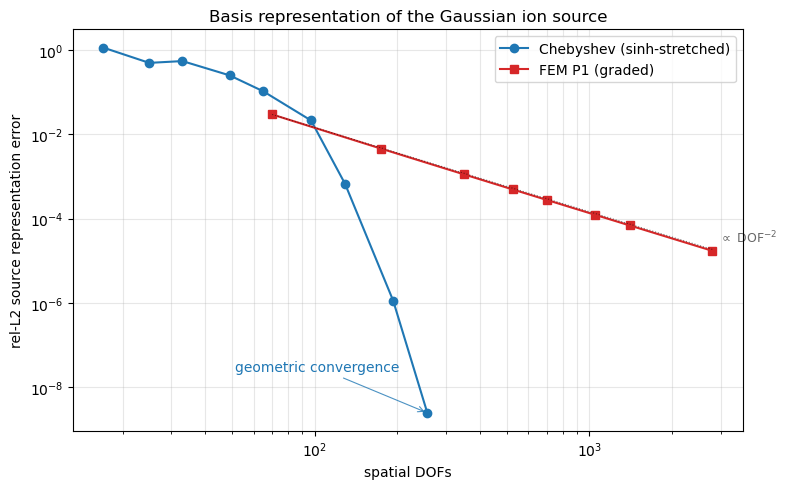

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(cheb_dofs, cheb_errs, "o-", color="C0", lw=1.5,
          label="Chebyshev (sinh-stretched)")
ax.loglog(fem_dofs, fem_errs, "s-", color="C3", lw=1.5,
          label="FEM P1 (graded)")

# slope-2 reference line for FEM
d_lo, d_hi = min(fem_dofs), max(fem_dofs)
e_lo = fem_errs[0]
ax.loglog([d_lo, d_hi], [e_lo, e_lo * (d_hi / d_lo) ** -2],
          "k:", lw=0.8, alpha=0.5)
ax.annotate(r"$\propto$ DOF$^{-2}$",
            xy=(d_hi, e_lo * (d_hi / d_lo) ** -2),
            xytext=(5, 5), textcoords="offset points",
            fontsize=9, alpha=0.6)

# Annotate the asymptotic Chebyshev tail as geometric convergence.
ax.annotate("geometric convergence",
            xy=(cheb_dofs[-1], cheb_errs[-1]),
            xytext=(-20, 30), textcoords="offset points",
            fontsize=10, color="C0", ha="right",
            arrowprops=dict(arrowstyle="->", color="C0",
                            lw=0.8, alpha=0.8))

ax.set_xlabel("spatial DOFs")
ax.set_ylabel(r"rel-L2 source representation error")
ax.set_title("Basis representation of the Gaussian ion source")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.tight_layout(); plt.show()


### 4.3 Markers of geometric convergence

Drawing a $\rho^{-N}$ reference line through the tail of the
log-log plot is suggestive, but it is not a proof on its own.
Geometric convergence means the error follows $\varepsilon_N \sim
C \rho^{-N}$ for some $\rho > 1$, with the $-N$ in the exponent
producing decay much faster than any algebraic rate. Taking the
logarithm gives $\log \varepsilon_N \sim \log C - N \log \rho$,
which is linear in $N$ — not in $\log N$, which is what algebraic
convergence is linear in. This distinction shows up on three
diagnostics, and the Chebyshev data should pass each one in the
asymptotic regime.

1. **Straight line on a semi-log axis.** Plotting $\log
\varepsilon$ against $N$ (linear in $N$, log in $\varepsilon$),
geometric convergence appears as a straight line with slope
$-\log \rho$. Algebraic convergence $\varepsilon \sim N^{-p}$
curves on the same axes, since it is straight only on log-log.
2. **Constant local rate.** Defining $\alpha_N = -d(\ln
\varepsilon)/dN$, geometric convergence gives a constant
$\alpha = \log \rho$ regardless of where it is measured.
Algebraic convergence has $\alpha_N \sim p / N$, which drifts
toward 0 as $N$ grows.
3. **Concave curve on the log-log axis.** The headline plot
above is log-log, where geometric convergence shows as a curve
that bends downward rather than a straight line. The FEM data
is straight on log-log because P1 gives algebraic convergence;
the Chebyshev data has to bend, since the same data cannot be
straight on both kinds of axes at once.

The cell below runs all three tests. Pre-asymptotic behaviour is
part of the story too: at low $N$, before the nodes densify
enough to resolve the source, the Chebyshev errors and local
rates are erratic, and the geometric pattern only locks in once
$N \gtrsim 100$.


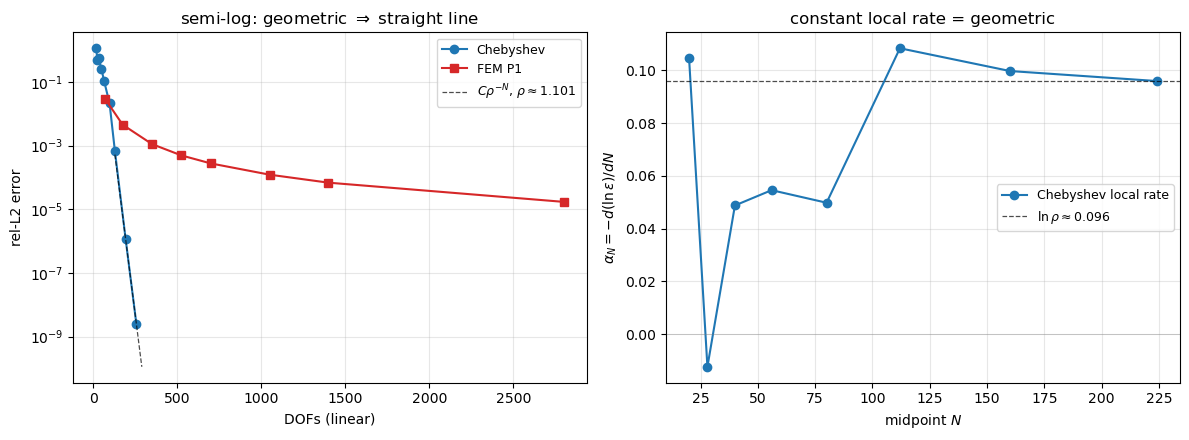

Chebyshev local rate alpha = -d(ln eps)/dN
(constant alpha => geometric, eps ~ exp(-alpha N))

  N1 -> N2        alpha    effective rho
  16 -> 24      +0.1045            1.110
  24 -> 32      -0.0123            0.988
  32 -> 48      +0.0488            1.050
  48 -> 64      +0.0546            1.056
  64 -> 96      +0.0498            1.051
  96 -> 128     +0.1083            1.114
 128 -> 192     +0.0997            1.105
 192 -> 256     +0.0959            1.101


In [36]:
# Diagnostic: run the three markers of geometric convergence on the
# Chebyshev data.

# Fit the asymptotic geometric rate from the two largest-N points.
N1, N2 = N_values[-2], N_values[-1]
rho = np.exp((np.log(cheb_errs[-2]) - np.log(cheb_errs[-1])) / (N2 - N1))
C_cheb = cheb_errs[-1] * rho ** N2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: semi-log error vs DOFs.  Geometric => straight line in the
# asymptotic regime; algebraic FEM should curve on these axes.
ax1.semilogy(cheb_dofs, cheb_errs, "o-", color="C0", lw=1.5,
             label="Chebyshev")
ax1.semilogy(fem_dofs, fem_errs, "s-", color="C3", lw=1.5,
             label="FEM P1")
N_line = np.linspace(N_values[-3], N_values[-1] + 32, 100)
ax1.semilogy(N_line + 1, C_cheb * rho ** (-N_line), "k--", lw=0.9,
             alpha=0.7,
             label=fr"$C\rho^{{-N}}$, $\rho \approx {rho:.3f}$")
ax1.set_xlabel("DOFs (linear)")
ax1.set_ylabel(r"rel-L2 error")
ax1.set_title(r"semi-log: geometric $\Rightarrow$ straight line")
ax1.grid(alpha=0.3, which="both")
ax1.legend(fontsize=9)

# Right: local exponential rate alpha_N = -d(ln eps)/dN for Chebyshev.
# Constant alpha => geometric; alpha drifting toward 0 => algebraic.
cheb_local = []
cheb_mid_N = []
for i in range(len(N_values) - 1):
    dN = N_values[i + 1] - N_values[i]
    cheb_local.append(-np.log(cheb_errs[i + 1] / cheb_errs[i]) / dN)
    cheb_mid_N.append(0.5 * (N_values[i] + N_values[i + 1]))

ax2.plot(cheb_mid_N, cheb_local, "o-", color="C0",
         label="Chebyshev local rate")
ax2.axhline(np.log(rho), color="k", ls="--", lw=0.9, alpha=0.7,
            label=fr"$\ln\rho \approx {np.log(rho):.3f}$")
ax2.axhline(0, color="gray", lw=0.5, alpha=0.5)
ax2.set_xlabel("midpoint $N$")
ax2.set_ylabel(r"$\alpha_N = -d(\ln\varepsilon)/dN$")
ax2.set_title("constant local rate = geometric")
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print the local rates as a table so the constant-alpha plateau is
# visible numerically as well.
print("Chebyshev local rate alpha = -d(ln eps)/dN")
print("(constant alpha => geometric, eps ~ exp(-alpha N))\n")
print(f"{'N1':>4} -> {'N2':<4}   {'alpha':>8}   {'effective rho':>14}")
for i in range(len(N_values) - 1):
    dN = N_values[i + 1] - N_values[i]
    a = -np.log(cheb_errs[i + 1] / cheb_errs[i]) / dN
    print(f"{N_values[i]:>4d} -> {N_values[i + 1]:<4d}   "
          f"{a:>+8.4f}   {np.exp(a):>14.3f}")


## 5. Reading the result

Numbers to look up from the table above:

- **Chebyshev at production $N+1 = 65$**: this is what
  `tds_inverse.ipynb` uses by default. If the rel-L2 here is well
  below $10^{-2}$, the spectral basis isn't the bottleneck.
- **FEM at production scale = 1** (~700 vertices): the workshop
  default. Same question — is the rel-L2 below $10^{-2}$?

If both methods clear the 1% bar at their production DOF counts,
then any error showing up in the full simulation comes from
somewhere else: time-stepper truncation, trap-reaction stiffness,
or surface-flux quadrature — *not* source resolution.

If one or both methods are **above** the 1% bar, the production
mesh is under-resolved at the spatial-input level and refining
won't change the time-stepper or Newton story until the basis
representation gets there first.

## 6. What this notebook does not test

This is a basis-representation test, not a discrete-operator test.
Two things it deliberately ignores:

1. **The discrete diffusion operator** $D \partial_x^2 c$. Even if a
   basis represents $c$ exactly, the discrete second-derivative
   matrix introduces its own error (which is the dominant FEM error
   for elliptic problems and the main reason spectral methods win
   per DOF). To probe that, apply each method's discrete
   $\partial_x^2$ to a known smooth function (e.g. $\sin(\pi
   x/L)$, which has analytic second derivative) and measure the
   rel-L2 against the analytic answer.
2. **The boundary-condition enforcement.** Both methods enforce
   $c(0) = c(L) = 0$ exactly at the boundary nodes; the
   *between-node* behaviour is what the Lagrange or P1 basis
   produces, and that's already covered by the source test if the
   source decays smoothly to zero (which it does).

For now, this single source-representation diagnostic is enough to
answer "is my production grid resolving the input?" before spending
time on a forward solve.
